In [2]:
import numpy as np
import sympy as sp
import control as ct
import symcontools as sct
from symcontools import dp
import scipy as cp

import matplotlib
import matplotlib.pyplot as plt


dict_keys(['__header__', '__version__', '__globals__', 'err', 'ke', 'kxku', 't', 'u', 'yp'])

In [141]:
m = cp.io.loadmat("./simulink/simlog2.mat", squeeze_me=True); dp(m.keys())

t = np.asarray(m["t"]).ravel()
u   = np.asarray(m["u"]).ravel()
yp = np.asarray(m["yp"])
kxku = np.asarray(m["kxku"])#.ravel()
ke   = np.asarray(m["ke"])          # (N,4)
err = np.asarray(m["err"])

dict_keys(['__header__', '__version__', '__globals__', 'err', 'ke', 'kxku', 't', 'u', 'yp'])

C:\Users\kawan\AppData\Local\Temp\ipykernel_59412\512007237.py:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


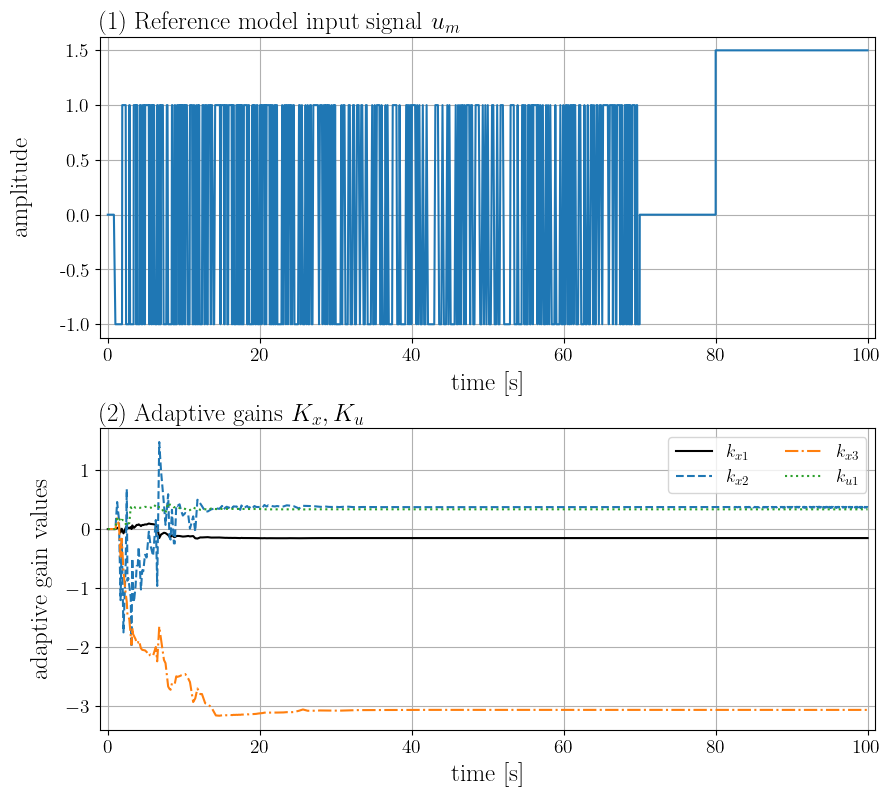

In [139]:


# （任意）間引き：重いなら step を 5,10,20... に
step_u = 1
step_k = 5



plt.rcParams.update({
    "font.size": 18,          # 基本サイズ
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# （任意）LaTeX組版（TeX環境があるなら）
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    sharex=True,
    figsize=(10, 9),
    gridspec_kw={"height_ratios": [2.0, 2.0], "hspace": 0.3},
)

# 上段：u_m
ax1.plot(t[::step_u], u[::step_u], linewidth=1.5)


styles = ['-', '--', '-.', ':']
colors = ['k', 'tab:blue', 'tab:orange', 'tab:green']

for i in range(kxku.shape[1]):
    ax2.plot(
        t[::step_k],
        kxku[::step_k, i],
        linestyle=styles[i],
        color=colors[i],
        linewidth=1.5
    )

ax1.set_ylabel(r"amplitude", labelpad = 20)
ax1.grid(True)
ax1.tick_params(axis="x", labelbottom=True)
ax1.set_xlim(-1, 101)
ax1.set_xlabel(r"time $[\mathrm{s}]$")
# 下段：kkxulog（4本）
#ax2.plot(k_t[::step_k], K[::step_k, :], linewidth=1.5)
ax2.set_xlabel(r"time $[\mathrm{s}]$")
ax2.set_ylabel(r"adaptive gain values", labelpad = 10)
ax2.grid(True)

# 凡例：2×2
ax2labels = [r"$k_{x 1}$", r"$k_{x 2}$", r"$k_{x 3}$", r"$k_{u 1}$"]
ax2.legend(ax2labels, ncol=2, loc="upper right", frameon=True)

# 軸範囲を揃えたいなら（例）
# ax2.set_xlim(0, 500)

#ax1.set_ylim(-0.2, 4.2)
#ax2.set_ylim(-1.5, 1.1)


ax1.set_title(r"(1) Reference model input signal $u_m$", loc="left")
ax2.set_title(r"(2) Adaptive gains $K_x, K_u$", loc="left")

ax1.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()
plt.show()
fig.savefig("two_panel.pdf", bbox_inches="tight", pad_inches=0.030)  # 外枠を切って保存


C:\Users\kawan\AppData\Local\Temp\ipykernel_59412\377136923.py:83: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


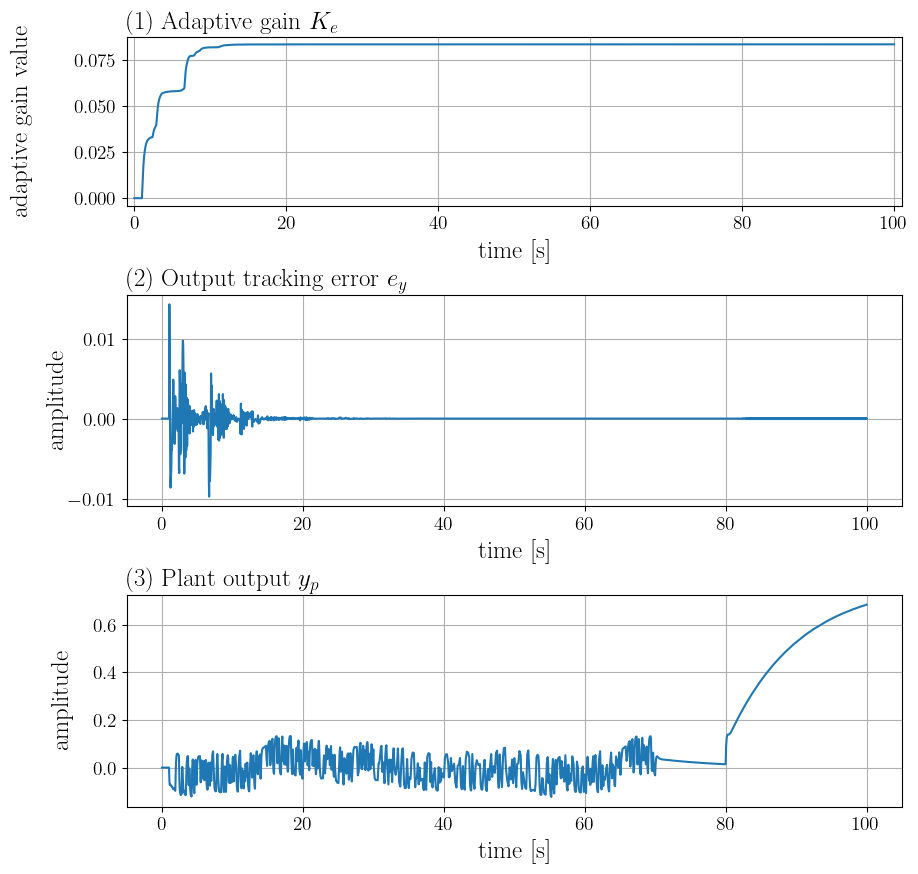

In [142]:


# （任意）間引き：重いなら step を 5,10,20... に
step_u = 1
step_k = 1



plt.rcParams.update({
    "font.size": 18,          # 基本サイズ
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
})

# （任意）LaTeX組版（TeX環境があるなら）
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

fig, (ax1, ax2, ax3) = plt.subplots(
    3, 1,
    #sharex=True,
    figsize=(10, 10),
    gridspec_kw={"height_ratios": [0.8, 1.0, 1.0], "hspace": 0.45},
)

# 上段：u_m
ax1.plot(t[::step_u], ke[::step_u], linewidth=1.5)
ax2.plot(t[::step_u], err[::step_u], linewidth=1.5)
ax3.plot(t[::step_u], yp[::step_u], linewidth=1.5)
"""
styles = ['-', '--', '-.', ':']
colors = ['k', 'tab:blue', 'tab:orange', 'tab:green']

for i in range(kxku.shape[1]):
    ax2.plot(
        t[::step_k],
        kxku[::step_k, i],
        linestyle=styles[i],
        color=colors[i],
        linewidth=1.5
    )
"""


ax1.grid(True)
ax2.grid(True)
ax3.grid(True)

ax1.set_xlim(-1, 101)

# 下段：kkxulog（4本）
#ax2.plot(k_t[::step_k], K[::step_k, :], linewidth=1.5)


ax1.set_ylabel(r"adaptive gain value", labelpad = 30)
ax2.set_ylabel(r"amplitude", labelpad = 0)
ax3.set_ylabel(r"amplitude", labelpad = 14)

ax3.set_xlabel(r"time $[\mathrm{s}]$")
ax2.set_xlabel(r"time $[\mathrm{s}]$")
ax1.set_xlabel(r"time $[\mathrm{s}]$")



# 凡例：2×2
#ax2labels = [r"$k_{x 1}$", r"$k_{x 2}$", r"$k_{x 3}$", r"$k_{u 1}$"]
#ax2.legend(ax2labels, ncol=2, loc="upper right", frameon=True)

# 軸範囲を揃えたいなら（例）
# ax2.set_xlim(0, 500)

#ax2.set_ylim(-0.005, 0.016)
#ax3.set_ylim(-0.2, 0.35)


ax1.set_title(r"(1) Adaptive gain $K_e$", loc="left")
ax2.set_title(r"(2) Output tracking error $e_y$", loc="left")
ax3.set_title(r"(3) Plant output $y_p$", loc="left")

#ax1.yaxis.set_major_formatter(matplotlib.ticker.FormatStrFormatter('%.1f'))

fig.tight_layout()
plt.show()
fig.savefig("two_panel2.pdf", bbox_inches="tight", pad_inches=0.030)  # 外枠を切って保存


In [110]:
m = cp.io.loadmat("./simulink/zerodif.mat", squeeze_me=True); dp(m.keys())

zs = np.asarray(m["zs"]).ravel()
cs = np.asarray(m["cs"])
zs = zs
zs


dict_keys(['__header__', '__version__', '__globals__', 'cs', 'zs'])

array([-1.5, -1.4, -1.3, -1.2, -1.1, -1. , -0.9, -0.8, -0.7, -0.6, -0.5])

[-3.33285033e+01 -2.31038449e+01 -1.85190509e+01 -8.44154417e+00
 -7.30966158e+00  5.04285894e-06  5.54516360e+00  1.21320845e+01
  1.40489653e+01  1.96513062e+01  3.58490444e+01  6.55385173e+01
  1.11241286e+02  1.99851005e+02 -1.00691953e+02 -1.52919776e+02
 -9.75322208e+01 -8.59357125e+01 -3.00899190e+01 -2.15359871e+01
  1.52243950e+01]
[-8.34045170e+01 -6.60047853e+01 -4.37318443e+01 -2.54816684e+01
 -1.56370333e+01  7.37644123e-06  1.12419674e+01  2.64651767e+01
  2.79818891e+01  3.39309171e+01  3.76524002e+01  4.66735453e+01
  4.77685712e+01  6.16747674e+01  7.15721020e+01  5.89028442e+01
  5.82985110e+01  5.26183492e+01  7.69089952e+01  6.53264575e+01
  8.76950571e+01]
[-3.39973679e+01 -3.43762417e+01 -1.88403376e+01 -1.35520524e+01
 -5.52677579e+00  1.03559721e-05  4.01835270e+00  1.01845079e+01
  1.09921201e+01  1.30006523e+01  1.75451742e+01  2.02036078e+01
  1.93686797e+01  2.37575359e+01  3.67600173e+01  2.80455466e+01
  2.90289756e+01  2.89929091e+01  2.65801697e+01  2.63

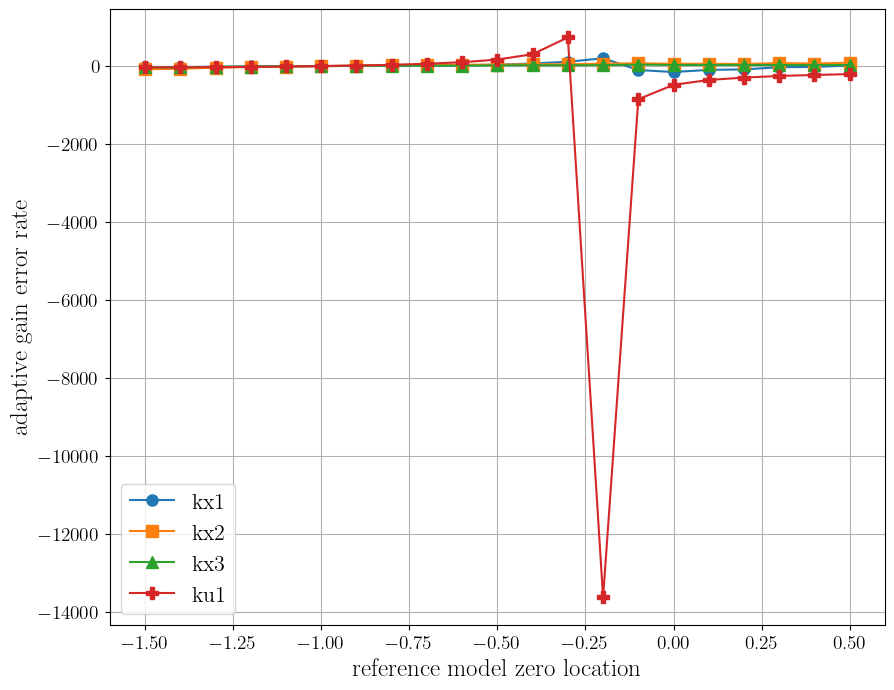

In [107]:


plt.figure(figsize=(10, 8))

plt.rcParams.update({
    "font.size": 20,          # 基本サイズ
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

# 3つの系列をループしてプロット
markers = ['o', 's', '^', "P"]
for i, y_data in enumerate(cs):
    print(y_data)
    if i < 3:
        plt.plot(zs, y_data, marker=markers[i], label=f'kx{i+1}', markersize=8)
    else:
        plt.plot(zs, y_data, marker=markers[i], label="ku1", markersize=8)

# 軸ラベルとタイトルの設定
plt.xlabel('reference model zero location')
plt.ylabel('adaptive gain error rate')
#plt.title('Line Plot of km vs Bf')

plt.grid(True) # グリッド（目盛線）を表示
plt.legend() # 凡例を表示
plt.show()

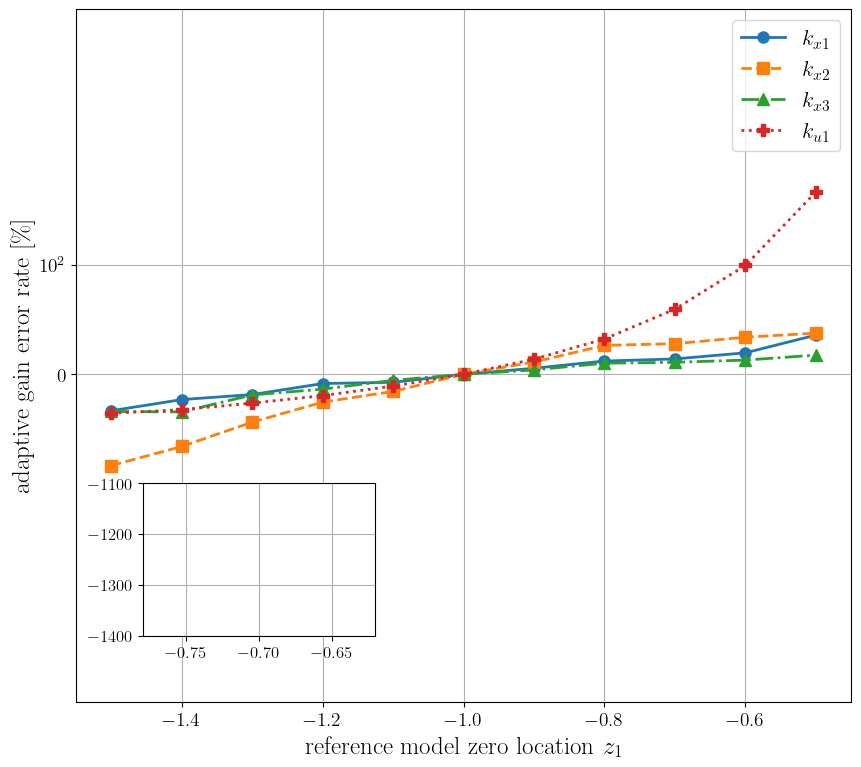

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.figure(figsize=(10, 9))

plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

zs_arr = np.asarray(zs, dtype=float)
markers = ['o', 's', '^', 'P']
linstyles=["-", "--", "-.", ":"]

# 主図で見たいyレンジ（ここを調整）
ylow, yhigh = -300, 400

# 外れ値小窓のyレンジ（ここを調整）
yout_low, yout_high = -1400, -1100

# 外れ値の点（既知）
z_out = -0.7
idx_out = int(np.argmin(np.abs(zs_arr - z_out)))

ax = plt.gca()

# ===== 主図（通常レンジだけ描く：レンジ外はNaNにして線が変にならないように） =====
for i, y_data in enumerate(cs):
    y = np.asarray(y_data, dtype=float)

    if i < 3:
        label = rf'$k_{{x{i+1}}}$'
    else:
        label = r'$k_{u1}$'   # ついでに下付き表記

    ax.plot(
        zs_arr, y,
        marker=markers[i], markersize=8,
        label=label,
        linestyle=linstyles[i], linewidth=2
    )

ax.set_ylim(ylow, yhigh)
ax.set_xlabel(r'reference model zero location $z_{1}$')
ax.set_ylabel(r'adaptive gain error rate [\%]')
ax.grid(True)
ax.legend(loc='upper right')
#ax.axvline(x=1, color='0.2', linewidth=2)
#ax.axhline(y=0, color='0.2', linewidth=2)
ax.set_yscale("symlog", linthresh=300)
# 主図に inset が見ている x 範囲を帯で示す
#ax.axvspan(z_out - xpad, z_out + xpad, alpha=0.15, zorder=0)
#from mpl_toolkits.axes_grid1.inset_locator import mark_inset
#mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.2", lw=1.5)

# ===== inset（外れ値付近） =====
axins = inset_axes(ax, width="30%", height="22%", loc="lower left", borderpad=3)

for i, y_data in enumerate(cs):
    y = np.asarray(y_data, dtype=float)
    axins.plot(
        zs_arr, y,
        marker=markers[i], markersize=6,
        linestyle=linstyles[i], linewidth=2
    )


# 外れ値点を強調（任意）
y_ku1 = np.asarray(cs[3], dtype=float)  # ku1が4番目(=i==3)という前提
axins.plot([zs_arr[idx_out]], [y_ku1[idx_out]], marker='P', markersize=10, linestyle='None', color="red")

# insetの表示範囲：xは外れ値の周囲だけに絞ると分かりやすい
xpad = 0.08
axins.set_xlim(z_out - xpad, z_out + xpad)
axins.set_ylim(yout_low, yout_high)

axins.grid(True)
axins.tick_params(labelsize=12)
plt.savefig("two_panelaa.pdf", bbox_inches="tight")#, pad_inches=0.030)
plt.show()


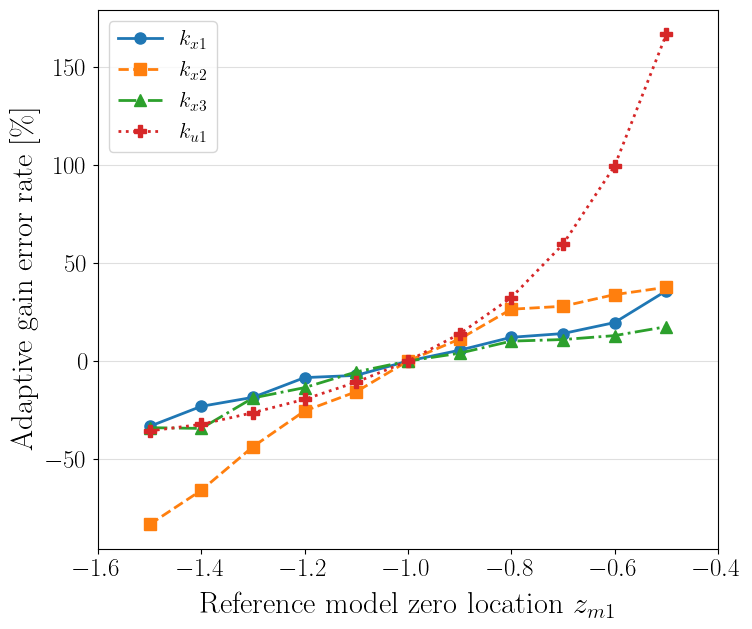

In [136]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.figure(figsize=(8, 7))
"""
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 16,
})
"""

plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

zs_arr = np.asarray(zs, dtype=float)
markers = ['o', 's', '^', 'P']
linstyles=["-", "--", "-.", ":"]


ax = plt.gca()

# ===== 主図（通常レンジだけ描く：レンジ外はNaNにして線が変にならないように） =====
for i, y_data in enumerate(cs):
    y = np.asarray(y_data, dtype=float)

    if i < 3:
        label = rf'$k_{{x{i+1}}}$'
    else:
        label = r'$k_{u1}$'   # ついでに下付き表記

    ax.plot(
        zs_arr, y,
        marker=markers[i], markersize=8,
        label=label,
        linestyle=linstyles[i], linewidth=2
    )

#ax.set_ylim(-300, 400)
ax.set_xlim(-1.6, -0.4)
ax.set_xlabel(r'Reference model zero location $z_{m 1}$', fontsize=22, labelpad=8)
ax.set_ylabel(r'Adaptive gain error rate [\%]', fontsize=22)
ax.grid(axis="y", which="both", alpha=0.4)
ax.legend(loc='upper left')
#ax.axvline(x=1, color='0.2', linewidth=2)
#ax.axhline(y=0, color='0.2', linewidth=2)
#ax.set_yscale("symlog", linthresh=100)


plt.savefig("two_panelaa.pdf", bbox_inches="tight")#, pad_inches=0.030)
plt.show()


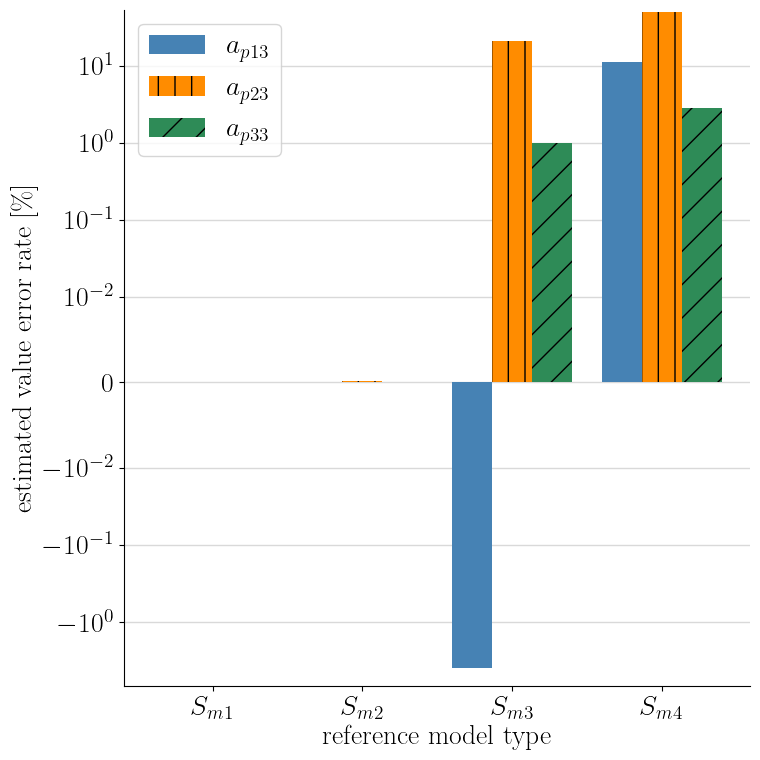

In [33]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
  "text.usetex": True,
  "font.family": "serif",
  "pgf.texsystem": "pdflatex"
})

def grouped_bar(ax, Y, xlabels=None, series_labels=None, width=0.8):
    """
    Y: shape (n_series, n_points) の2次元配列（系列×点）
    xlabels: 各点のラベル（長さ n_points）
    series_labels: 各系列のラベル（長さ n_series）
    width: 1グループ全体の幅（0～1くらい）
    """
    Y = np.asarray(Y)
    if Y.ndim != 2:
        raise ValueError("Y must be 2D: (n_series, n_points)")

    n_series, n_points = Y.shape
    x = np.arange(n_points)

    bar_w = width / n_series
    offsets = (np.arange(n_series) - (n_series - 1) / 2) * bar_w

    for i in range(n_series):
        label = series_labels[i] if series_labels is not None else None
        ax.bar(x + offsets[i], Y[i], width=bar_w, label=label, color=colors[i], hatch=hatches[i])

    ax.set_xticks(x)
    if xlabels is not None:
        ax.set_xticklabels(xlabels)

    ax.yaxis.grid(True, color="0.85", linewidth=1)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return ax


# ===== 使用例（4系列）=====
xlabels = [r"$S_{m1}$", r"$S_{m2}$", r"$S_{m3}$", r"$S_{m4}$"]
Y = np.array([
    [-7*10e-3, 0.017, -6*10e-3, 0.1],   # series 1
    [-0.025, -3.7*10e-3, 0.054, -0.07],   # series 2
    [-32, -26, -57, -35],   # series 3
    [-54, -42, -120, -46],   # series 4
]).T
Y = np.array([
    [-0.13, 0.35, 0.11],   # series 1
    [0.18, -0.95, -0.096],   # series 2
    [-4.6, -26, 47],   # series 3
    [-4.1, -27, 130],   # series 4
]).T
Y = np.array([
    [-1.4e-6, 5e-6, -6e-6],   # series 1
    [-9e-6, 0.0002, 1e-5],   # series 2
    [-4, 21, 1],   # series 3
    [11, 50, 2.8],   # series 4
]).T


series_labels = [r"$a_{p 13}$", r"$a_{p 23}$", r"$a_{p 33}$",]
hatches = ["", "|", "/"]
colors = ["steelblue", "darkorange", "seagreen"]
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
})

fig, ax = plt.subplots(figsize=(8, 8))
grouped_bar(ax, Y, xlabels=xlabels, series_labels=series_labels, width=0.8)

#ax.set_ylim(-100, 1)
ax.set_yscale("symlog", linthresh=0.01)
ax.legend(ncol=1, loc="upper left",  frameon=True)

ax.set_xlabel(r'reference model type')
ax.set_ylabel(r'estimated value error rate [\%]')
#ax.grid(True)

plt.tight_layout()
plt.savefig("esterr.pdf", bbox_inches="tight")
plt.show()

C:\Users\kawan\AppData\Local\Temp\ipykernel_59412\1680648901.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


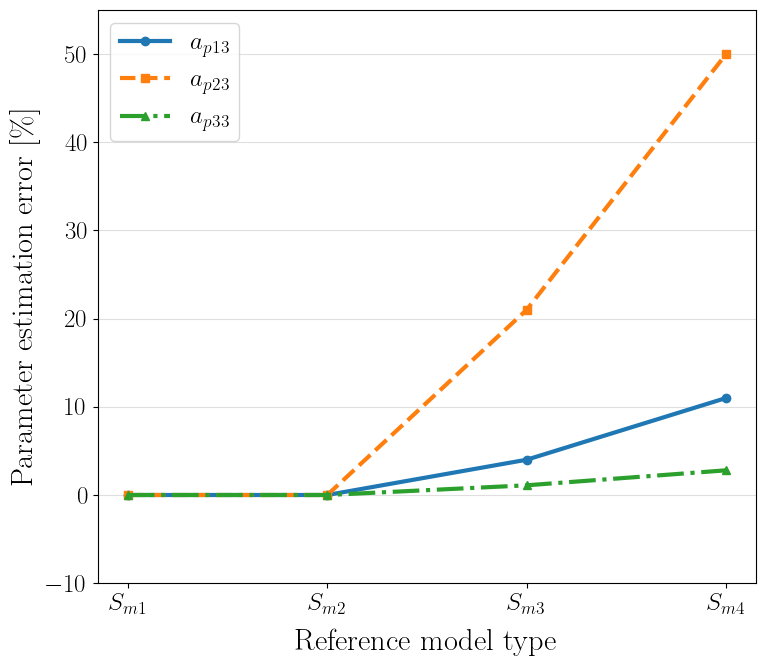

In [143]:
# figname = "serr"
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
})

labels = [r"$S_{m1}$", r"$S_{m2}$", r"$S_{m3}$", r"$S_{m4}$"]


Y = np.array([
    [6.4e-6, -7.6e-6, -8.5e-6],
    [4.5e-5, 1.1e-4, 1.8e-6],   # series 2
    [4, 21, 1.1],   # series 3
    [11, 50, 2.8],   # series 4
]).T


"""
data = [err_ap13, err_ap23, err_ap33]
"""
series_labels = [r"$a_{p 13}$", r"$a_{p 23}$", r"$a_{p 33}$",]

fig, ax = plt.subplots(figsize=(8, 7))

linstyles = ['-', '--', '-.', ':']
markers = ['o', 's', '^', 'D']
for i, d in enumerate(Y):
    ax.plot(labels, d, linestyle=linstyles[i], marker=markers[i], label=series_labels[i], linewidth=3)

#ax.set_yscale("symlog", linthresh=10)

ax.set_ylim(-10, 55)
ax.set_xticklabels(labels)
ax.set_ylabel(r"Parameter estimation error [\%]", fontsize=22)
ax.set_xlabel("Reference model type", fontsize=22, labelpad=10)
#ax.axhline(0, linewidth=0.8)
ax.grid(axis="y", which="both", alpha=0.4)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, series_labels, ncol=1, fontsize=18, loc="upper left", frameon=True)

plt.tight_layout()
plt.savefig("esterr.pdf", bbox_inches="tight")
plt.show()
